In [67]:
%load_ext autoreload
%autoreload 2


import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from synthetic_lc import (Oscillator, OscillatorCluster, WindowFunction,
                           NoiseModel, SyntheticLC, run_configs)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Example

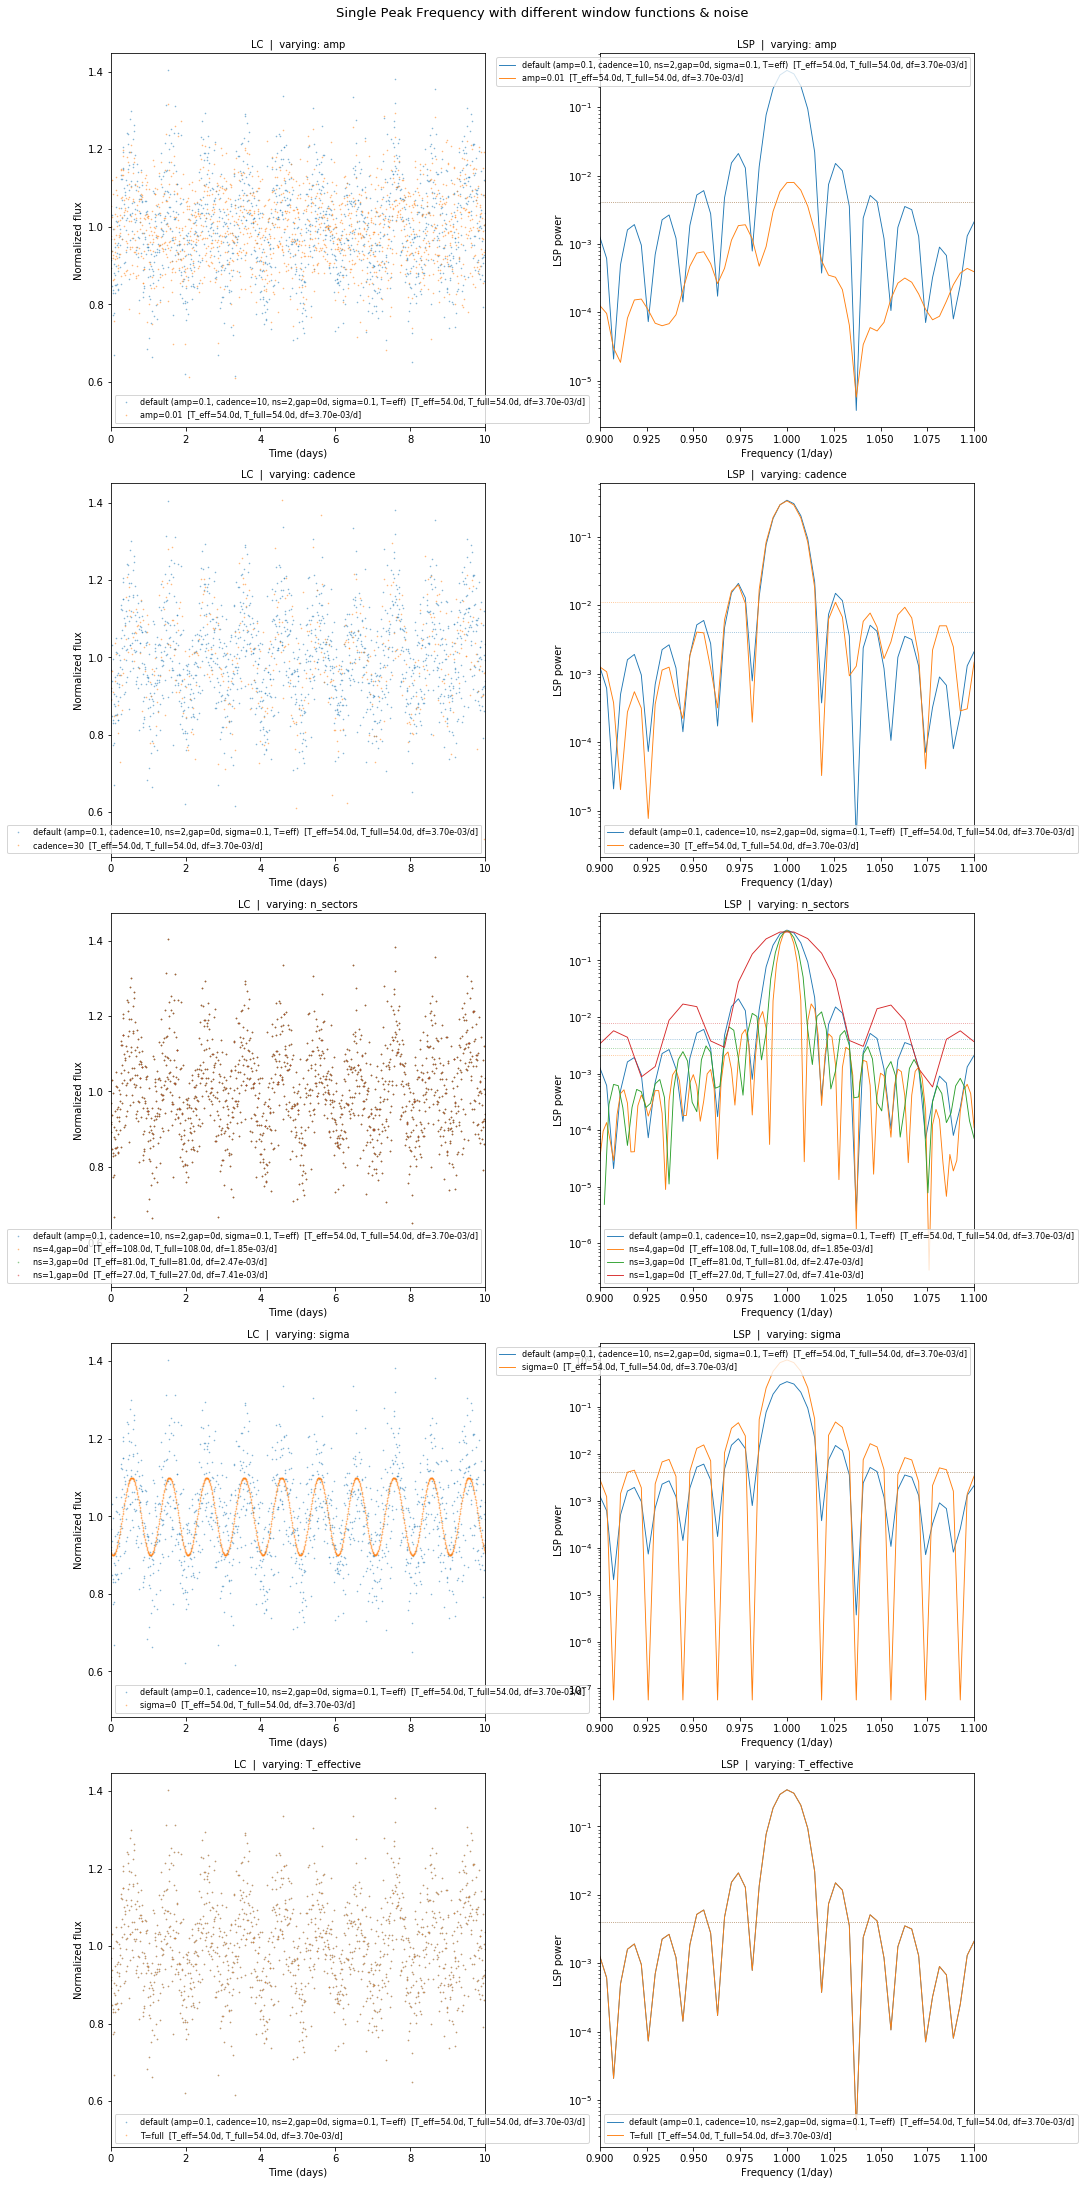

{'amp': {'default (amp=0.1, cadence=10, ns=2,gap=0d, sigma=0.1, T=eff)  [T_eff=54.0d, T_full=54.0d, df=3.70e-03/d]': {'freqs': array([0.1       , 0.1037037 , 0.10740741, ..., 9.98888889, 9.99259259,
          9.9962963 ]),
   'power': array([4.53156728e-05, 2.78341184e-05, 1.25397914e-05, ...,
          1.78083712e-04, 1.95560392e-04, 1.58560047e-04]),
   'max_power': 0.34431831003685265,
   'freq_at_max_power': 1.0,
   'period_at_max_power': 1.0,
   'fap_threshold': 0.0040776477748290145,
   'SumPow_10_7': 0.0008650934916347245,
   'SumPow_7_4': 0.00553405292011343,
   'SumPow_4_1': 1.0516581329851298,
   'SumPow_1_p5': 1.0966040985815166},
  'amp=0.01  [T_eff=54.0d, T_full=54.0d, df=3.70e-03/d]': {'freqs': array([0.1       , 0.1037037 , 0.10740741, ..., 9.98888889, 9.99259259,
          9.9962963 ]),
   'power': array([1.02542387e-04, 7.53665729e-05, 3.32699634e-05, ...,
          2.86021746e-04, 3.12130712e-04, 2.47963428e-04]),
   'max_power': 0.007940215512738262,
   'freq_at_max_

In [2]:
BASE_CONFIG = dict(
    # Oscillator
    N                  = [1],
    freq_distribution  = ['uniform'],
    freq               = [1.0],
    freq_width         = [0],
    amp_distribution   = ['uniform'],
    amp                = [0.1, 0.01],
    amp_width          = [0],

    # LC / window  (n_sectors: list of (n_sectors, gap_durations) tuples)
    FullLC_Baseline    = 10000,
    sector_length      = [27.0],
    cadence            = [10.0, 30.0],
    n_sectors          = [
                          (2, [0]),
                          (4, [0, 0, 0]),
                          (3, [0, 0]),
                          (1, [])],

    # Noise
    sigma              = [0.1, 0],

    # LSP
    T_effective        = [True, False],
    P_min              = [0.1],
    P_max              = [10],
    alpha              = [5],
)

run_configs(
    BASE_CONFIG,
    title='Single Peak Frequency with different window functions & noise',
    yscale='log',
    xscale='linear',
    x_lim=(0.9, 1.1),
    figsize=(15, 30),
    multipanel=True,
    plot_LC=True,
    LC_xlim=[0, 10],
)

# How does T_eff vs. T_full and frequeny Bin Sizes Effect a Single Peak?

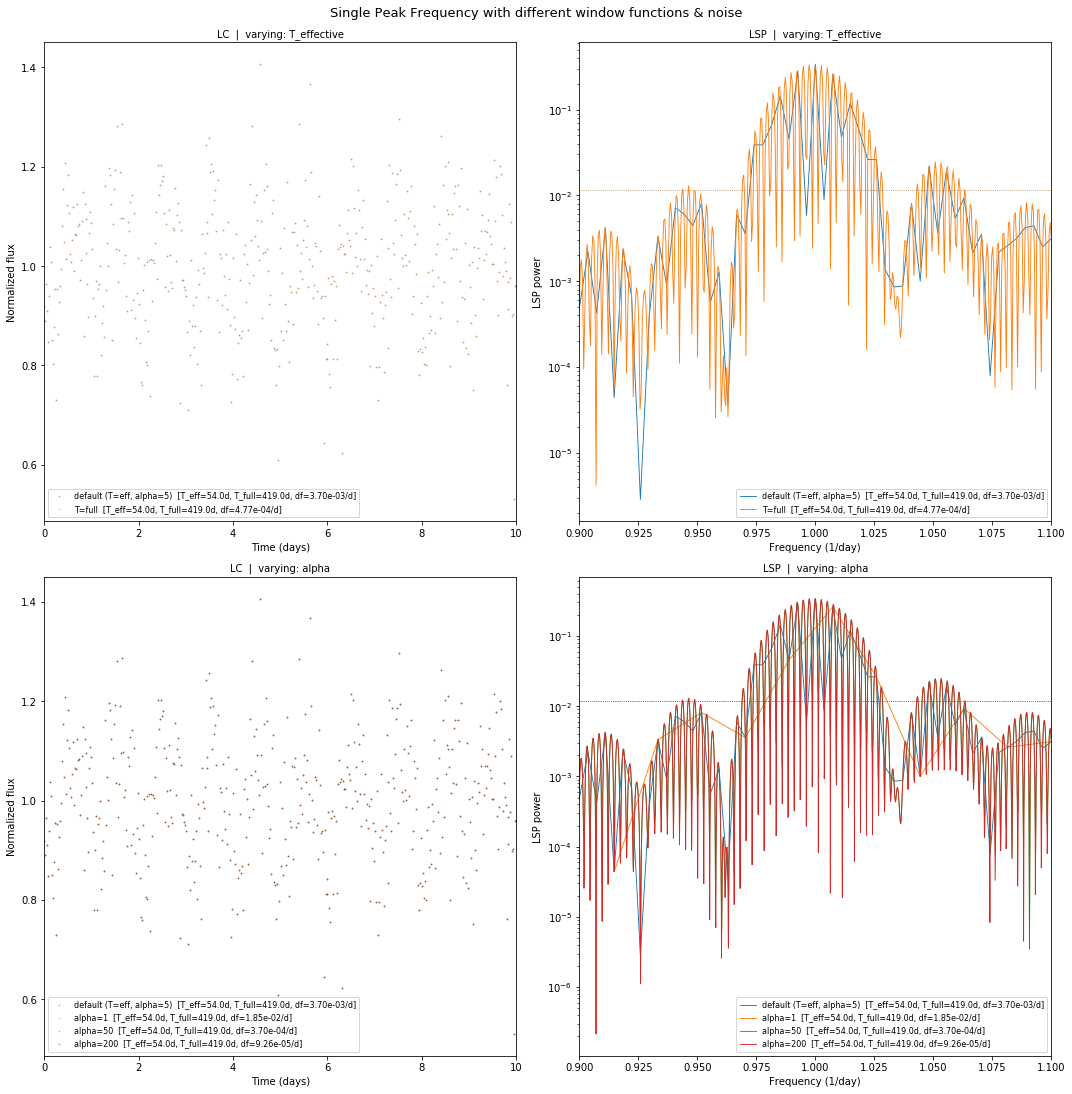

{'T_effective': {'default (T=eff, alpha=5)  [T_eff=54.0d, T_full=419.0d, df=3.70e-03/d]': {'freqs': array([0.1       , 0.1037037 , 0.10740741, ..., 9.98888889, 9.99259259,
          9.9962963 ]),
   'power': array([1.45019081e-04, 2.84535268e-05, 1.12277727e-04, ...,
          3.61133762e-04, 2.73094715e-04, 8.94184582e-05]),
   'max_power': 0.339005939390856,
   'freq_at_max_power': 1.0,
   'period_at_max_power': 1.0,
   'fap_threshold': 0.01170196285392605,
   'SumPow_10_7': 0.005364215481939654,
   'SumPow_7_4': 0.025253345483625154,
   'SumPow_4_1': 1.1220032282579842,
   'SumPow_1_p5': 1.1354521311347638},
  'T=full  [T_eff=54.0d, T_full=419.0d, df=4.77e-04/d]': {'freqs': array([0.1       , 0.10047733, 0.10095465, ..., 9.99832936, 9.99880668,
          9.99928401]),
   'power': array([1.45019081e-04, 1.16872938e-04, 3.25732644e-05, ...,
          9.62264650e-05, 5.04808069e-05, 1.59738989e-04]),
   'max_power': 0.33327230243777517,
   'freq_at_max_power': 0.9973747016706443,
   'p

In [35]:
BASE_CONFIG = dict(
    # Oscillator
    N                  = [1],
    freq_distribution  = ['uniform'],
    freq               = [1.0],
    freq_width         = [0],
    amp_distribution   = ['uniform'],
    amp                = [0.1],
    amp_width          = [0],

    # LC / window  (n_sectors: list of (n_sectors, gap_durations) tuples)
    FullLC_Baseline    = 10000,
    sector_length      = [27.0],
    cadence            = [30.0],
    n_sectors          = [(2, [365])],

    # Noise
    sigma              = [0.1],

    # LSP
    T_effective        = [True, False],
    P_min              = [0.1],
    P_max              = [10],
    alpha              = [5, 1, 50, 200],
)

run_configs(
    BASE_CONFIG,
    title='Single Peak Frequency with different window functions & noise',
    yscale='log',
    xscale='linear',
    x_lim=(0.9, 1.1),
    figsize=(15, 15),
    multipanel=True,
    plot_LC=True,
    LC_xlim=[0, 10],
)

# How does Window Function and Baseline Effect Width of peak?

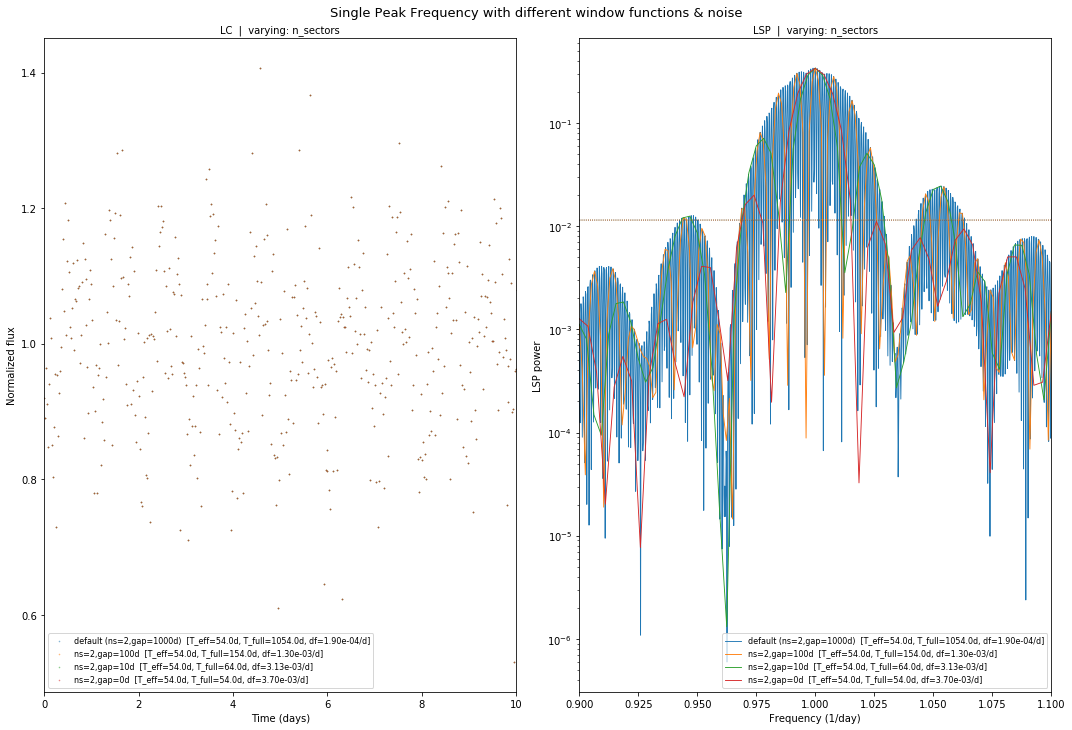

{'n_sectors': {'default (ns=2,gap=1000d)  [T_eff=54.0d, T_full=1054.0d, df=1.90e-04/d]': {'freqs': array([0.1       , 0.10018975, 0.10037951, ..., 9.99943074, 9.99962049,
          9.99981025]),
   'power': array([1.00143584e-05, 4.51656771e-05, 1.21203702e-04, ...,
          6.51270657e-05, 6.71736289e-05, 2.13781317e-04]),
   'max_power': 0.3390075827423455,
   'freq_at_max_power': 1.0,
   'period_at_max_power': 1.0,
   'fap_threshold': 0.011733477681713546,
   'SumPow_10_7': 0.1040726699669608,
   'SumPow_7_4': 0.494310202605523,
   'SumPow_4_1': 18.77924615399759,
   'SumPow_1_p5': 19.001988219133512},
  'ns=2,gap=100d  [T_eff=54.0d, T_full=154.0d, df=1.30e-03/d]': {'freqs': array([0.1      , 0.1012987, 0.1025974, ..., 9.9961039, 9.9974026,
          9.9987013]),
   'power': array([1.00143584e-05, 2.63890317e-05, 9.31259930e-05, ...,
          8.06822691e-05, 1.72045134e-04, 2.80866065e-04]),
   'max_power': 0.33900490726287896,
   'freq_at_max_power': 1.0,
   'period_at_max_power'

In [43]:
BASE_CONFIG = dict(
    # Oscillator
    N                  = [1],
    freq_distribution  = ['uniform'],
    freq               = [1.0],
    freq_width         = [0],
    amp_distribution   = ['uniform'],
    amp                = [0.1],
    amp_width          = [0],

    # LC / window  (n_sectors: list of (n_sectors, gap_durations) tuples)
    FullLC_Baseline    = 10000,
    sector_length      = [27.0],
    cadence            = [30.0],
    n_sectors          = [(2, [1000]),
                          (2, [100]),
                          (2, [10]),
                          (2, [0]),
                         ],

    # Noise
    sigma              = [0.1],

    # LSP
    T_effective        = [False],
    P_min              = [0.1],
    P_max              = [10],
    alpha              = [5],
)

run_configs(
    BASE_CONFIG,
    title='Single Peak Frequency with different window functions & noise',
    yscale='log',
    xscale='linear',
    x_lim=(0.9, 1.1),
    figsize=(15, 10),
    multipanel=True,
    plot_LC=True,
    LC_xlim=[0, 10],
)

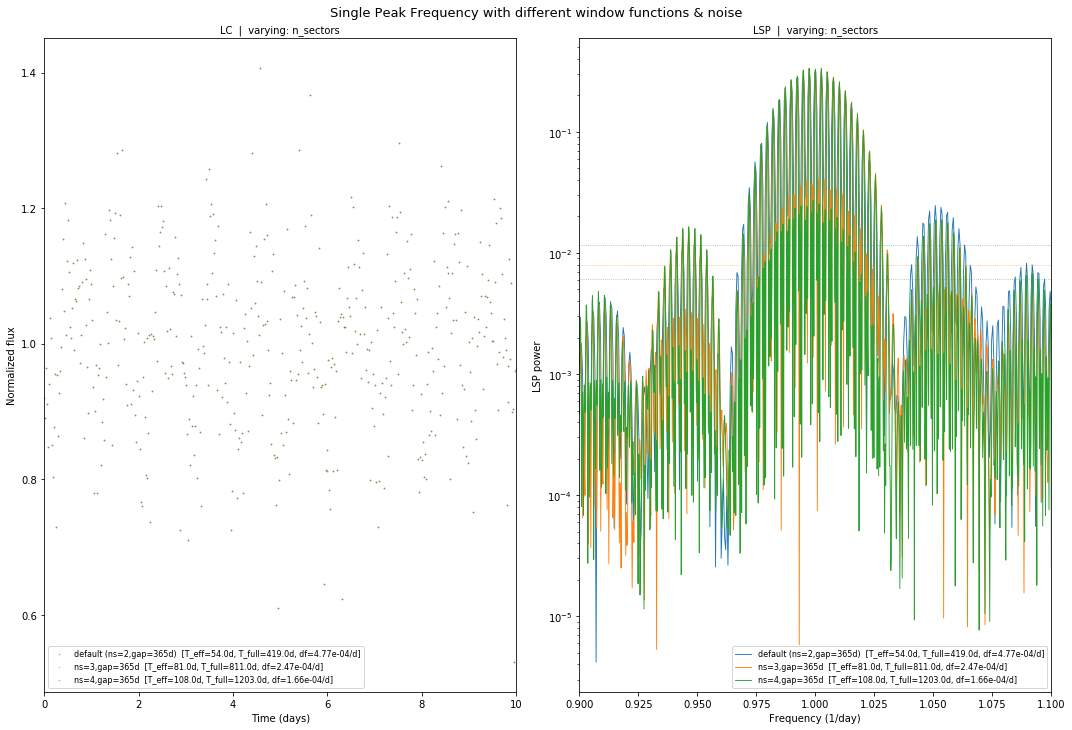

{'n_sectors': {'default (ns=2,gap=365d)  [T_eff=54.0d, T_full=419.0d, df=4.77e-04/d]': {'freqs': array([0.1       , 0.10047733, 0.10095465, ..., 9.99832936, 9.99880668,
          9.99928401]),
   'power': array([1.45019081e-04, 1.16872938e-04, 3.25732644e-05, ...,
          9.62264650e-05, 5.04808069e-05, 1.59738989e-04]),
   'max_power': 0.33327230243777517,
   'freq_at_max_power': 0.9973747016706443,
   'period_at_max_power': 1.0026322086623594,
   'fap_threshold': 0.01170196285392605,
   'SumPow_10_7': 0.04127328449035938,
   'SumPow_7_4': 0.19728567886517415,
   'SumPow_4_1': 7.39355151666062,
   'SumPow_1_p5': 7.49041400973669},
  'ns=3,gap=365d  [T_eff=81.0d, T_full=811.0d, df=2.47e-04/d]': {'freqs': array([0.1       , 0.10024661, 0.10049322, ..., 9.99913687, 9.99938348,
          9.99963009]),
   'power': array([1.68905143e-04, 3.10089688e-04, 3.13219612e-04, ...,
          4.98001686e-05, 2.34321790e-05, 2.29419012e-04]),
   'max_power': 0.3359683316567953,
   'freq_at_max_powe

In [48]:
BASE_CONFIG = dict(
    # Oscillator
    N                  = [1],
    freq_distribution  = ['uniform'],
    freq               = [1.0],
    freq_width         = [0],
    amp_distribution   = ['uniform'],
    amp                = [0.1],
    amp_width          = [0],

    # LC / window  (n_sectors: list of (n_sectors, gap_durations) tuples)
    FullLC_Baseline    = 10000,
    sector_length      = [27.0],
    cadence            = [30.0],
    n_sectors          = [(2, [365]),
                          (3, [365]*2),
                          (4, [365]*3),
                         ],

    # Noise
    sigma              = [0.1],

    # LSP
    T_effective        = [False],
    P_min              = [0.1],
    P_max              = [10],
    alpha              = [5],
)

run_configs(
    BASE_CONFIG,
    title='Single Peak Frequency with different window functions & noise',
    yscale='log',
    xscale='linear',
    x_lim=(0.9, 1.1),
    figsize=(15, 10),
    multipanel=True,
    plot_LC=True,
    LC_xlim=[0, 10],
)

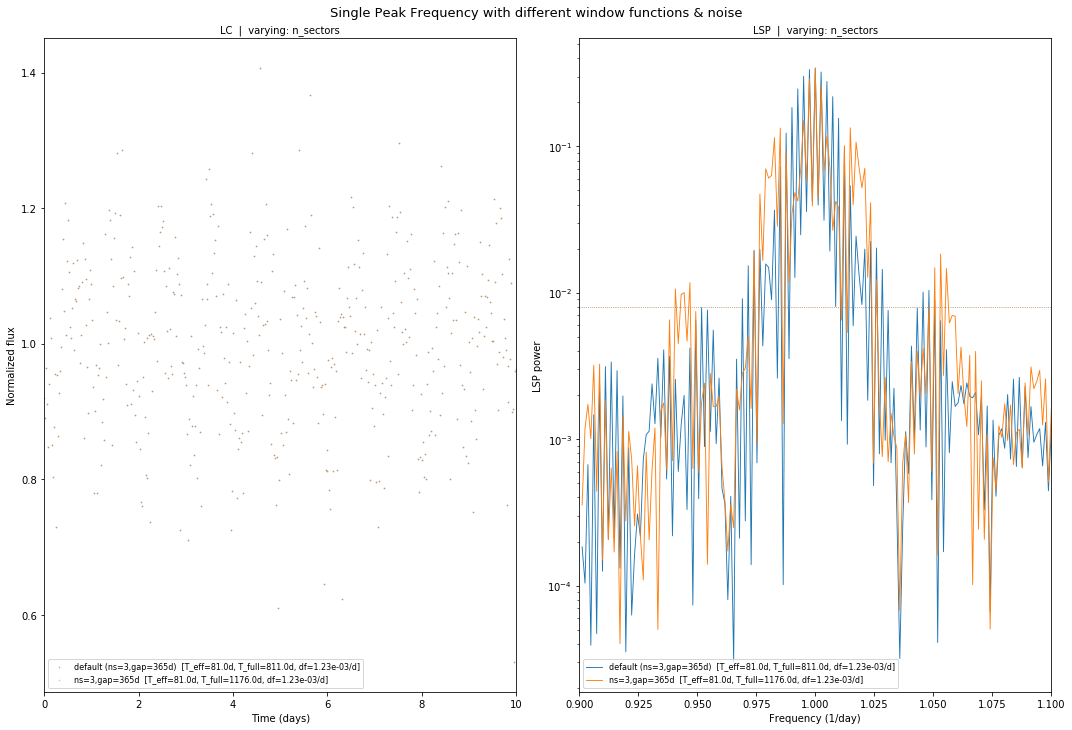

{'n_sectors': {'default (ns=3,gap=365d)  [T_eff=81.0d, T_full=811.0d, df=1.23e-03/d]': {'freqs': array([0.1       , 0.10123457, 0.10246914, ..., 9.9962963 , 9.99753086,
          9.99876543]),
   'power': array([1.68905143e-04, 9.73239401e-05, 1.66656809e-04, ...,
          2.20962949e-04, 4.98113857e-04, 2.28542785e-04]),
   'max_power': 0.34239582016200837,
   'freq_at_max_power': 1.0,
   'period_at_max_power': 1.0,
   'fap_threshold': 0.007937028711199934,
   'SumPow_10_7': 0.01324396742322777,
   'SumPow_7_4': 0.039684418897510565,
   'SumPow_4_1': 2.1894649144078437,
   'SumPow_1_p5': 2.1118892763095474},
  'ns=3,gap=365d  [T_eff=81.0d, T_full=1176.0d, df=1.23e-03/d]': {'freqs': array([0.1       , 0.10123457, 0.10246914, ..., 9.9962963 , 9.99753086,
          9.99876543]),
   'power': array([1.92400027e-04, 1.01178222e-04, 2.89039326e-04, ...,
          1.77023075e-04, 4.27985505e-04, 5.61483512e-05]),
   'max_power': 0.34239581109628703,
   'freq_at_max_power': 1.0,
   'period_at

In [70]:
BASE_CONFIG = dict(
    # Oscillator
    N                  = [1],
    freq_distribution  = ['uniform'],
    freq               = [1.0],
    freq_width         = [0],
    amp_distribution   = ['uniform'],
    amp                = [0.1],
    amp_width          = [0],

    # LC / window  (n_sectors: list of (n_sectors, gap_durations) tuples)
    FullLC_Baseline    = 10000,
    sector_length      = [27.0],
    cadence            = [30.0],
    n_sectors          = [(3, [365]*2),
                          (3, [365, 365*2]),
                         ],

    # Noise
    sigma              = [0.1],

    # LSP
    T_effective        = [True],
    P_min              = [0.1],
    P_max              = [10],
    alpha              = [10],
)

run_configs(
    BASE_CONFIG,
    title='Single Peak Frequency with different window functions & noise',
    yscale='log',
    xscale='linear',
    x_lim=(0.9, 1.1),
    figsize=(15, 10),
    multipanel=True,
    plot_LC=True,
    LC_xlim=[0, 10],
)

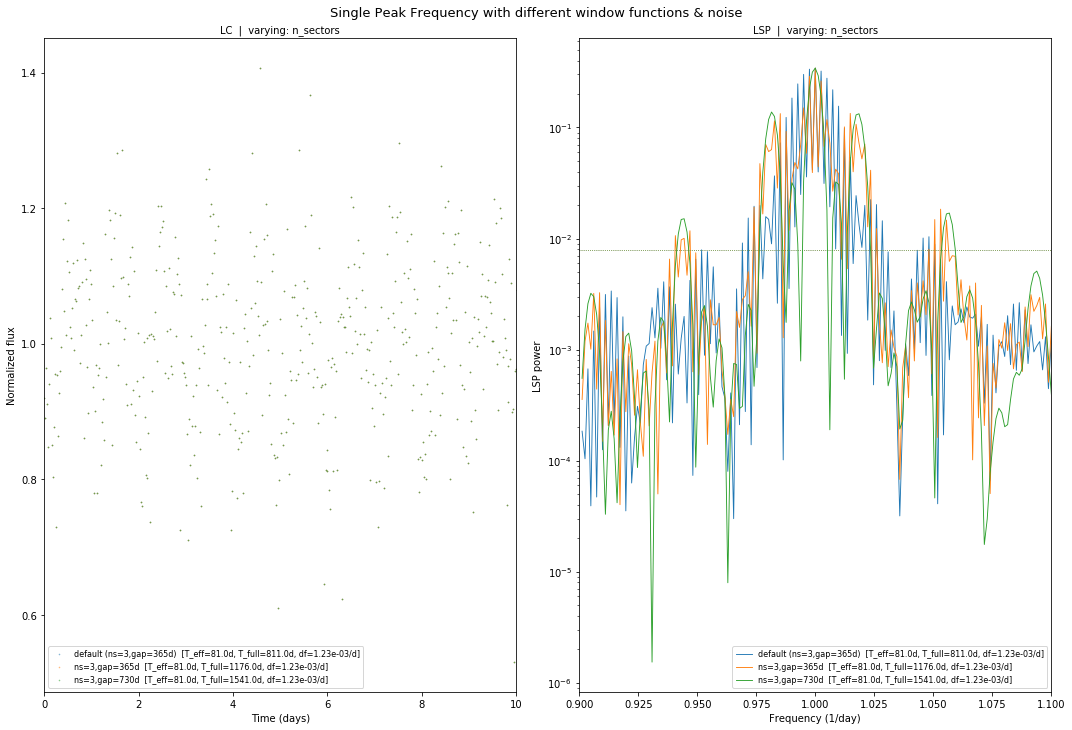

{'n_sectors': {'default (ns=3,gap=365d)  [T_eff=81.0d, T_full=811.0d, df=1.23e-03/d]': {'freqs': array([0.1       , 0.10123457, 0.10246914, ..., 9.9962963 , 9.99753086,
          9.99876543]),
   'power': array([1.68905143e-04, 9.73239401e-05, 1.66656809e-04, ...,
          2.20962949e-04, 4.98113857e-04, 2.28542785e-04]),
   'max_power': 0.34239582016200837,
   'freq_at_max_power': 1.0,
   'period_at_max_power': 1.0,
   'fap_threshold': 0.007937028711199934,
   'SumPow_10_7': 0.01324396742322777,
   'SumPow_7_4': 0.039684418897510565,
   'SumPow_4_1': 2.1894649144078437,
   'SumPow_1_p5': 2.1118892763095474},
  'ns=3,gap=365d  [T_eff=81.0d, T_full=1176.0d, df=1.23e-03/d]': {'freqs': array([0.1       , 0.10123457, 0.10246914, ..., 9.9962963 , 9.99753086,
          9.99876543]),
   'power': array([1.92400027e-04, 1.01178222e-04, 2.89039326e-04, ...,
          1.77023075e-04, 4.27985505e-04, 5.61483512e-05]),
   'max_power': 0.34239581109628703,
   'freq_at_max_power': 1.0,
   'period_at

In [71]:
BASE_CONFIG = dict(
    # Oscillator
    N                  = [1],
    freq_distribution  = ['uniform'],
    freq               = [1.0],
    freq_width         = [0],
    amp_distribution   = ['uniform'],
    amp                = [0.1],
    amp_width          = [0],

    # LC / window  (n_sectors: list of (n_sectors, gap_durations) tuples)
    FullLC_Baseline    = 10000,
    sector_length      = [27.0],
    cadence            = [30.0],
    n_sectors          = [(3, [365, 365]),
                          (3, [365, 365*2]),
                          (3, [365*2, 365*2]),

                         ],

    # Noise
    sigma              = [0.1],

    # LSP
    T_effective        = [True],
    P_min              = [0.1],
    P_max              = [10],
    alpha              = [10],
)

run_configs(
    BASE_CONFIG,
    title='Single Peak Frequency with different window functions & noise',
    yscale='log',
    xscale='linear',
    x_lim=(0.9, 1.1),
    figsize=(15, 10),
    multipanel=True,
    plot_LC=True,
    LC_xlim=[0, 10],
)

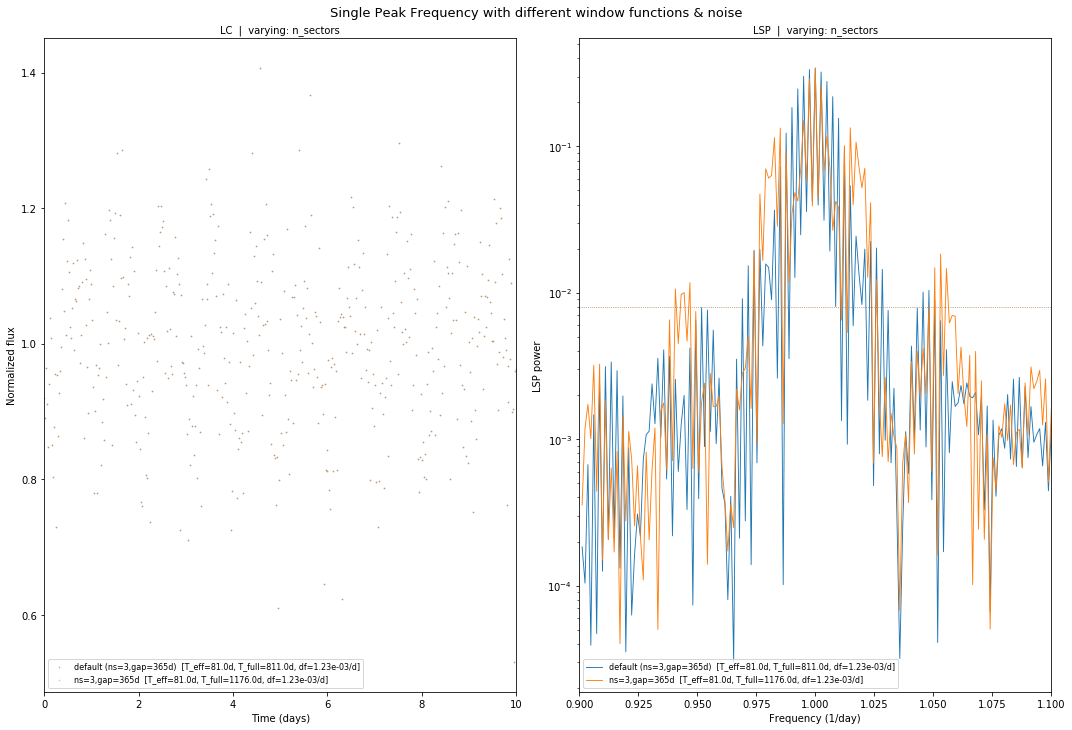

{'n_sectors': {'default (ns=3,gap=365d)  [T_eff=81.0d, T_full=811.0d, df=1.23e-03/d]': {'freqs': array([0.1       , 0.10123457, 0.10246914, ..., 9.9962963 , 9.99753086,
          9.99876543]),
   'power': array([1.68905143e-04, 9.73239401e-05, 1.66656809e-04, ...,
          2.20962949e-04, 4.98113857e-04, 2.28542785e-04]),
   'max_power': 0.34239582016200837,
   'freq_at_max_power': 1.0,
   'period_at_max_power': 1.0,
   'fap_threshold': 0.007937028711199934,
   'SumPow_10_7': 0.01324396742322777,
   'SumPow_7_4': 0.039684418897510565,
   'SumPow_4_1': 2.1894649144078437,
   'SumPow_1_p5': 2.1118892763095474},
  'ns=3,gap=365d  [T_eff=81.0d, T_full=1176.0d, df=1.23e-03/d]': {'freqs': array([0.1       , 0.10123457, 0.10246914, ..., 9.9962963 , 9.99753086,
          9.99876543]),
   'power': array([1.92400027e-04, 1.01178222e-04, 2.89039326e-04, ...,
          1.77023075e-04, 4.27985505e-04, 5.61483512e-05]),
   'max_power': 0.34239581109628703,
   'freq_at_max_power': 1.0,
   'period_at

In [60]:
BASE_CONFIG = dict(
    # Oscillator
    N                  = [1],
    freq_distribution  = ['uniform'],
    freq               = [1.0],
    freq_width         = [0],
    amp_distribution   = ['uniform'],
    amp                = [0.1],
    amp_width          = [0],

    # LC / window  (n_sectors: list of (n_sectors, gap_durations) tuples)
    FullLC_Baseline    = 10000,
    sector_length      = [27.0],
    cadence            = [30.0],
    n_sectors          = [(3, [365]*2),
                          (3, [365, 365*2]),
                         ],

    # Noise
    sigma              = [0.1],

    # LSP
    T_effective        = [True],
    P_min              = [0.1],
    P_max              = [10],
    alpha              = [10],
)

run_configs(
    BASE_CONFIG,
    title='Single Peak Frequency with different window functions & noise',
    yscale='log',
    xscale='linear',
    x_lim=(0.9, 1.1),
    figsize=(15, 10),
    multipanel=True,
    plot_LC=True,
    LC_xlim=[0, 10],
)

# What About N Oscilators

/astro/users/cgwill/TESS_Cluster_Age_ML/Data_Visualization_CGW/synthetic_lc.py:895: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/epyc/opt/anaconda/lib/python3.7/site-packages/IPython/core/pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


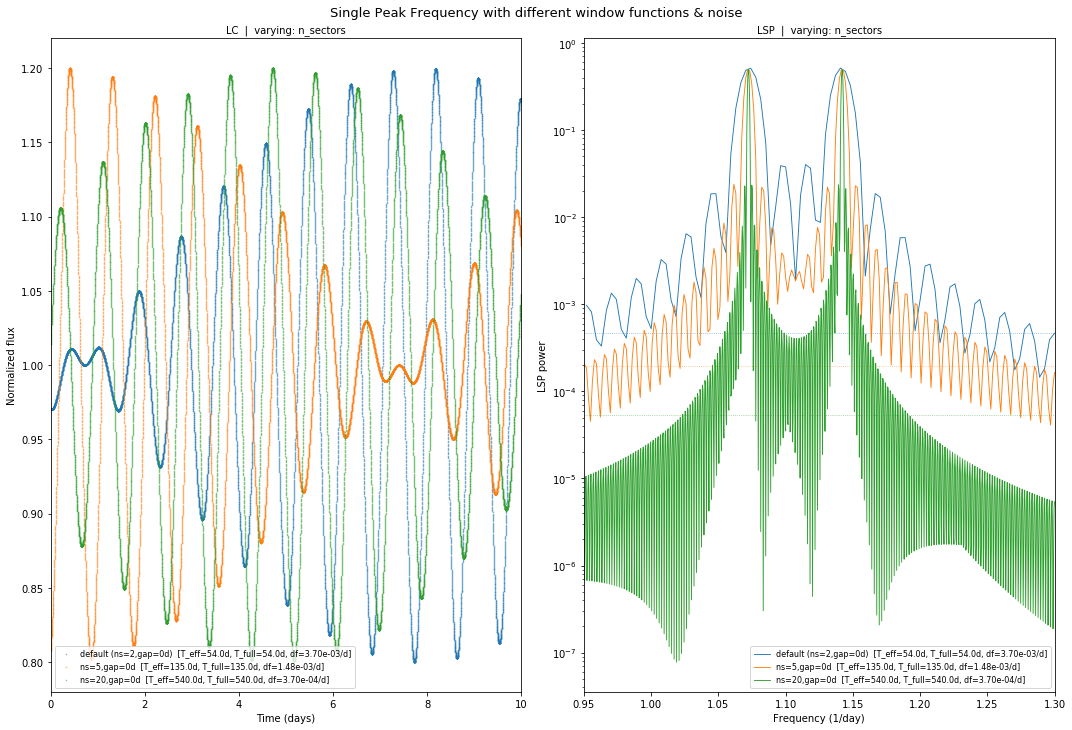

{'n_sectors': {'default (ns=2,gap=0d)  [T_eff=54.0d, T_full=54.0d, df=3.70e-03/d]': {'freqs': array([0.1       , 0.1037037 , 0.10740741, ..., 9.98888889, 9.99259259,
          9.9962963 ]),
   'power': array([4.05469125e-05, 3.98703168e-05, 3.21096587e-05, ...,
          2.20683109e-08, 8.70679220e-11, 1.92026023e-08]),
   'max_power': 0.5143744248228485,
   'freq_at_max_power': 1.1407407407407408,
   'period_at_max_power': 0.8766233766233765,
   'fap_threshold': 0.00046937716257980155,
   'SumPow_10_7': 0.0004239803930775978,
   'SumPow_7_4': 0.0010325249900929232,
   'SumPow_4_1': 0.034870435368947524,
   'SumPow_1_p5': 4.962097174483469},
  'ns=5,gap=0d  [T_eff=135.0d, T_full=135.0d, df=1.48e-03/d]': {'freqs': array([0.1       , 0.10148148, 0.10296296, ..., 9.99481481, 9.9962963 ,
          9.99777778]),
   'power': array([7.49658108e-07, 6.02963052e-07, 6.48024033e-07, ...,
          1.42782954e-07, 1.88397824e-07, 1.35779228e-07]),
   'max_power': 0.49994741315534624,
   'freq_at_

In [24]:
BASE_CONFIG = dict(
    # Oscillator
    N                  = [2],
    freq_distribution  = ['uniform'],
    freq               = [1.0],
    freq_width         = [0.2],
    amp_distribution   = ['uniform'],
    amp                = [0.1],
    amp_width          = [0],

    # LC / window  (n_sectors: list of (n_sectors, gap_durations) tuples)
    FullLC_Baseline    = 10000,
    sector_length      = [27.0],
    cadence            = [1.0],
    n_sectors          = [(2, [0]),
                          (5, [0]*4),
                          (20, [0]*19),
                         ],

    # Noise
    sigma              = [0],

    # LSP
    T_effective        = [False],
    P_min              = [0.1],
    P_max              = [10],
    alpha              = [5],
)

run_configs(
    BASE_CONFIG,
    title='Single Peak Frequency with different window functions & noise',
    yscale='log',
    xscale='linear',
    x_lim=(0.95, 1.3),
    figsize=(15, 10),
    multipanel=True,
    plot_LC=True,
    LC_xlim=[0, 10],
)

/astro/users/cgwill/TESS_Cluster_Age_ML/Data_Visualization_CGW/synthetic_lc.py:895: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/epyc/opt/anaconda/lib/python3.7/site-packages/IPython/core/pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


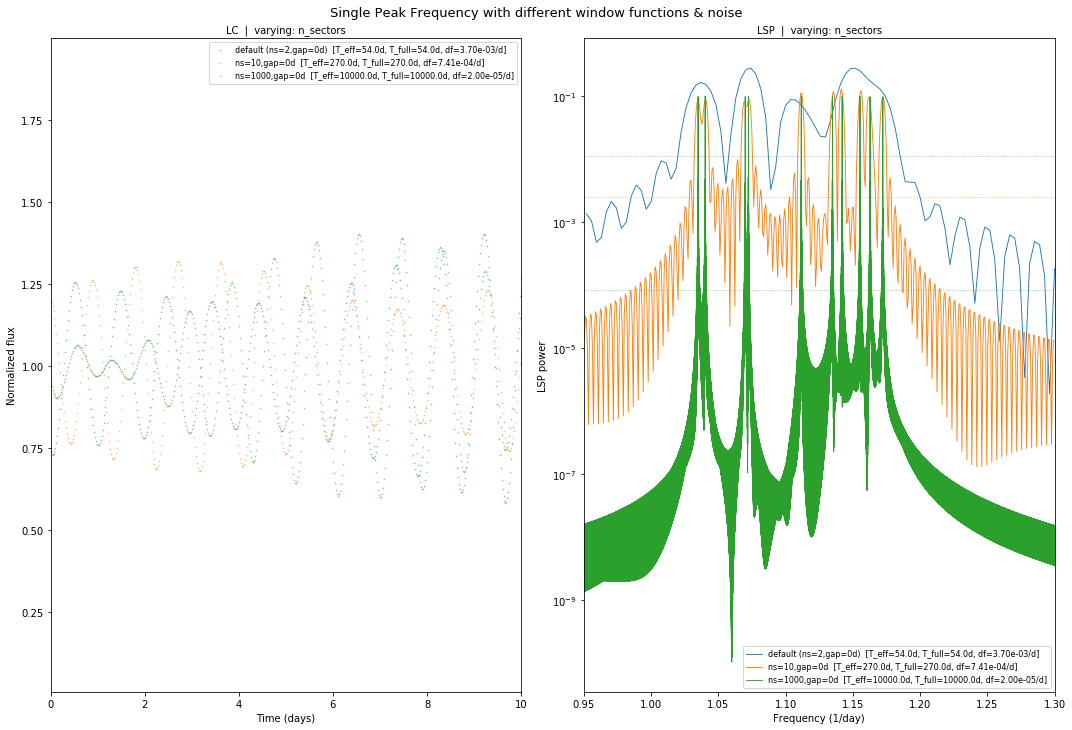

{'n_sectors': {'default (ns=2,gap=0d)  [T_eff=54.0d, T_full=54.0d, df=3.70e-03/d]': {'freqs': array([0.1       , 0.1037037 , 0.10740741, ..., 9.98888889, 9.99259259,
          9.9962963 ]),
   'power': array([1.04467806e-05, 9.48806238e-06, 3.52753920e-06, ...,
          5.81069653e-07, 2.61885525e-07, 8.03664952e-08]),
   'max_power': 0.2790606616141911,
   'freq_at_max_power': 1.0740740740740742,
   'period_at_max_power': 0.9310344827586206,
   'fap_threshold': 0.01132460041041661,
   'SumPow_10_7': 7.956513524004712e-05,
   'SumPow_7_4': 0.0001940099358867167,
   'SumPow_4_1': 0.040637812615291924,
   'SumPow_1_p5': 4.954284496171798},
  'ns=10,gap=0d  [T_eff=270.0d, T_full=270.0d, df=7.41e-04/d]': {'freqs': array([0.1       , 0.10074074, 0.10148148, ..., 9.99777778, 9.99851852,
          9.99925926]),
   'power': array([1.11434481e-08, 1.13807185e-08, 7.52071339e-08, ...,
          3.57488950e-09, 1.30977512e-08, 1.79217717e-08]),
   'max_power': 0.13019103315962705,
   'freq_at_ma

In [23]:
BASE_CONFIG = dict(
    # Oscillator
    N                  = [10],
    freq_distribution  = ['uniform'],
    freq               = [1.0],
    freq_width         = [0.2],
    amp_distribution   = ['uniform'],
    amp                = [0.1],
    amp_width          = [0],

    # LC / window  (n_sectors: list of (n_sectors, gap_durations) tuples)
    FullLC_Baseline    = 10000,
    sector_length      = [27.0],
    cadence            = [30.0],
    n_sectors          = [(2, [0]),
                          (10, [0]*9),
                          (1000, [0]*999),

                         ],

    # Noise
    sigma              = [0],

    # LSP
    T_effective        = [False],
    P_min              = [0.1],
    P_max              = [10],
    alpha              = [5],
)

run_configs(
    BASE_CONFIG,
    title='Single Peak Frequency with different window functions & noise',
    yscale='log',
    xscale='linear',
    x_lim=(0.95, 1.3),
    figsize=(15, 10),
    multipanel=True,
    plot_LC=True,
    LC_xlim=[0, 10],
)

/astro/users/cgwill/TESS_Cluster_Age_ML/Data_Visualization_CGW/synthetic_lc.py:895: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/epyc/opt/anaconda/lib/python3.7/site-packages/IPython/core/pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


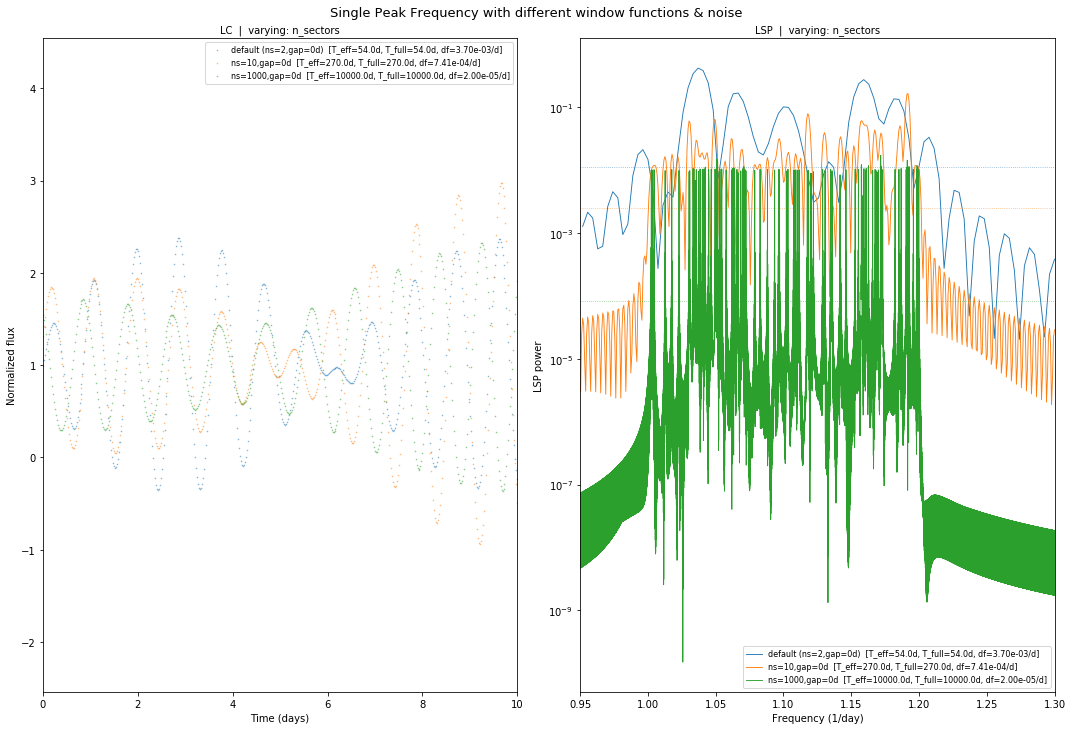

{'n_sectors': {'default (ns=2,gap=0d)  [T_eff=54.0d, T_full=54.0d, df=3.70e-03/d]': {'freqs': array([0.1       , 0.1037037 , 0.10740741, ..., 9.98888889, 9.99259259,
          9.9962963 ]),
   'power': array([4.77529019e-06, 7.35007911e-06, 1.85787990e-05, ...,
          9.91695462e-09, 1.71864830e-08, 1.86627978e-08]),
   'max_power': 0.41812965557104387,
   'freq_at_max_power': 1.0370370370370372,
   'period_at_max_power': 0.9642857142857141,
   'fap_threshold': 0.01132460041041661,
   'SumPow_10_7': 0.0001462762398054891,
   'SumPow_7_4': 0.00041355686553959164,
   'SumPow_4_1': 0.09836494075812226,
   'SumPow_1_p5': 4.913357840284181},
  'ns=10,gap=0d  [T_eff=270.0d, T_full=270.0d, df=7.41e-04/d]': {'freqs': array([0.1       , 0.10074074, 0.10148148, ..., 9.99777778, 9.99851852,
          9.99925926]),
   'power': array([2.52588891e-06, 1.61759077e-06, 2.38345205e-07, ...,
          5.41139526e-10, 3.35962101e-09, 4.97599934e-09]),
   'max_power': 0.1649553999867681,
   'freq_at_ma

In [25]:
BASE_CONFIG = dict(
    # Oscillator
    N                  = [100],
    freq_distribution  = ['uniform'],
    freq               = [1.0],
    freq_width         = [0.2],
    amp_distribution   = ['uniform'],
    amp                = [0.1],
    amp_width          = [0],

    # LC / window  (n_sectors: list of (n_sectors, gap_durations) tuples)
    FullLC_Baseline    = 10000,
    sector_length      = [27.0],
    cadence            = [30.0],
    n_sectors          = [(2, [0]),
                          (10, [0]*9),
                          (1000, [0]*999),

                         ],

    # Noise
    sigma              = [0],

    # LSP
    T_effective        = [False],
    P_min              = [0.1],
    P_max              = [10],
    alpha              = [5],
)

run_configs(
    BASE_CONFIG,
    title='Single Peak Frequency with different window functions & noise',
    yscale='log',
    xscale='linear',
    x_lim=(0.95, 1.3),
    figsize=(15, 10),
    multipanel=True,
    plot_LC=True,
    LC_xlim=[0, 10],
)

/astro/users/cgwill/TESS_Cluster_Age_ML/Data_Visualization_CGW/synthetic_lc.py:895: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/epyc/opt/anaconda/lib/python3.7/site-packages/IPython/core/pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


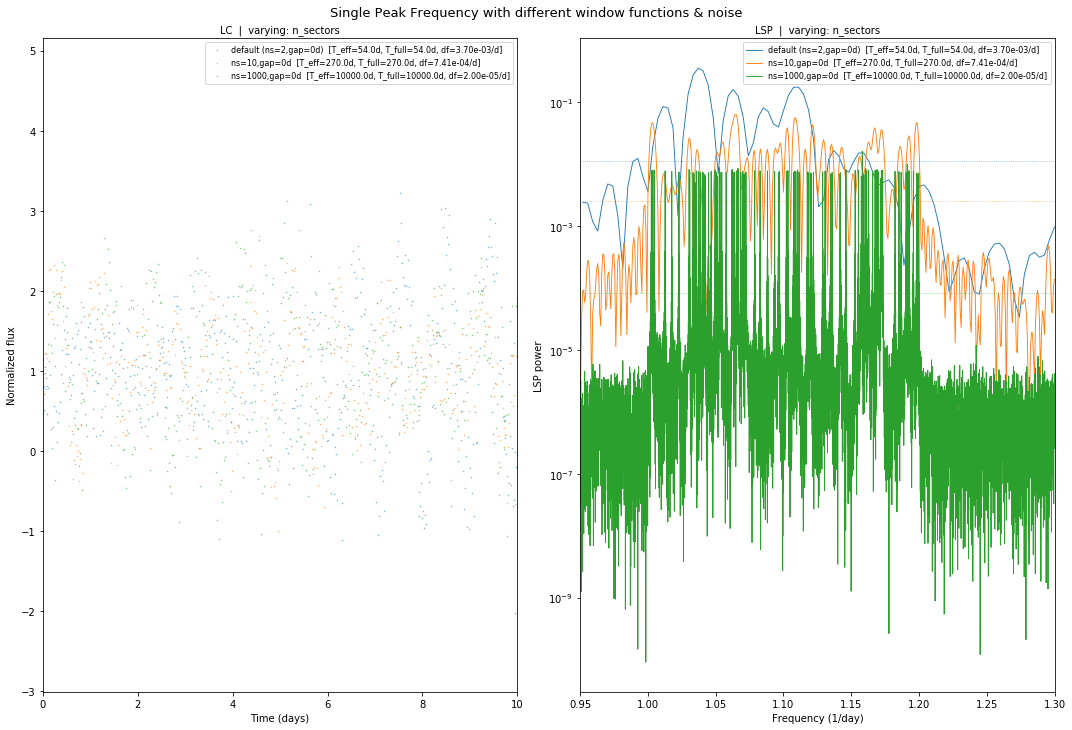

{'n_sectors': {'default (ns=2,gap=0d)  [T_eff=54.0d, T_full=54.0d, df=3.70e-03/d]': {'freqs': array([0.1       , 0.1037037 , 0.10740741, ..., 9.98888889, 9.99259259,
          9.9962963 ]),
   'power': array([3.78604456e-05, 1.81870773e-05, 6.63994045e-05, ...,
          1.77879740e-04, 1.43312388e-04, 1.13968242e-04]),
   'max_power': 0.3536310500175965,
   'freq_at_max_power': 1.0370370370370372,
   'period_at_max_power': 0.9642857142857141,
   'fap_threshold': 0.01132460041041656,
   'SumPow_10_7': 0.0022669355411800473,
   'SumPow_7_4': 0.013335870027851086,
   'SumPow_4_1': 0.11772462959456816,
   'SumPow_1_p5': 3.486039249242434},
  'ns=10,gap=0d  [T_eff=270.0d, T_full=270.0d, df=7.41e-04/d]': {'freqs': array([0.1       , 0.10074074, 0.10148148, ..., 9.99777778, 9.99851852,
          9.99925926]),
   'power': array([3.47907391e-05, 2.15535919e-05, 2.91493649e-06, ...,
          7.87040007e-06, 1.02585594e-05, 7.89890691e-06]),
   'max_power': 0.06338890259034966,
   'freq_at_max_

In [28]:
BASE_CONFIG = dict(
    # Oscillator
    N                  = [100],
    freq_distribution  = ['uniform'],
    freq               = [1.0],
    freq_width         = [0.2],
    amp_distribution   = ['uniform'],
    amp                = [0.1],
    amp_width          = [0],

    # LC / window  (n_sectors: list of (n_sectors, gap_durations) tuples)
    FullLC_Baseline    = 10000,
    sector_length      = [27.0],
    cadence            = [30.0],
    n_sectors          = [(2, [0]),
                          (10, [0]*9),
                          (1000, [0]*999),

                         ],

    # Noise
    sigma              = [0.4],

    # LSP
    T_effective        = [False],
    P_min              = [0.1],
    P_max              = [10],
    alpha              = [5],
)

run_configs(
    BASE_CONFIG,
    title='Single Peak Frequency with different window functions & noise',
    yscale='log',
    xscale='linear',
    x_lim=(0.95, 1.3),
    figsize=(15, 10),
    multipanel=True,
    plot_LC=True,
    LC_xlim=[0, 10],
)

/astro/users/cgwill/TESS_Cluster_Age_ML/Data_Visualization_CGW/synthetic_lc.py:895: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/epyc/opt/anaconda/lib/python3.7/site-packages/IPython/core/pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


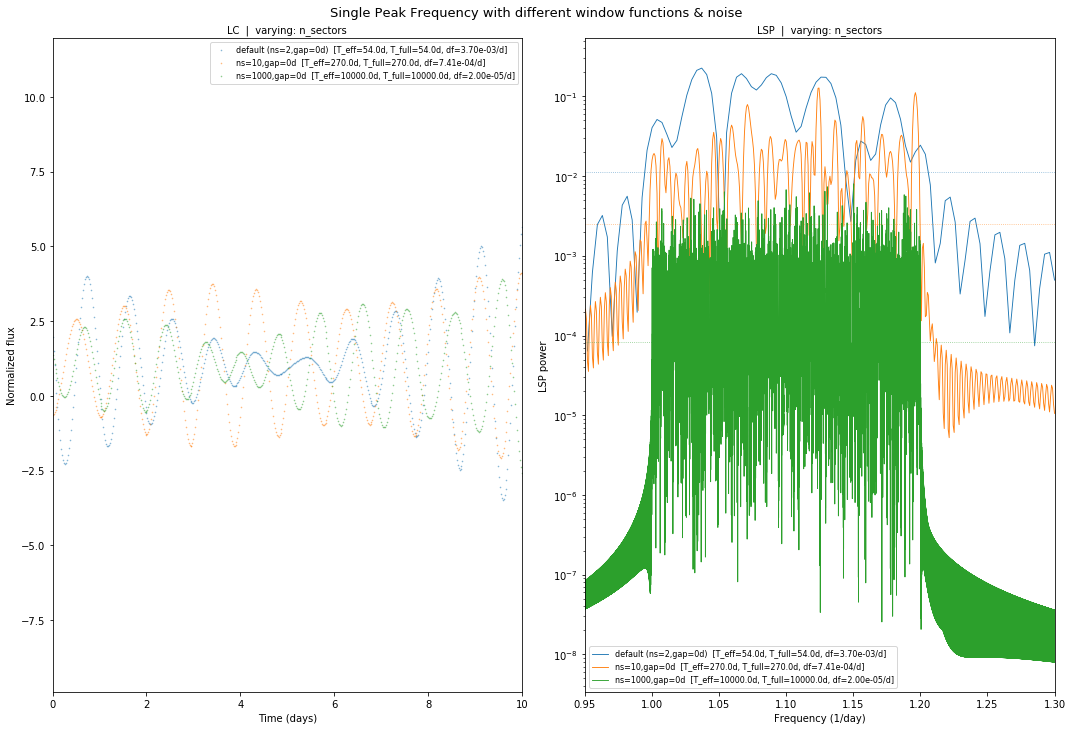

{'n_sectors': {'default (ns=2,gap=0d)  [T_eff=54.0d, T_full=54.0d, df=3.70e-03/d]': {'freqs': array([0.1       , 0.1037037 , 0.10740741, ..., 9.98888889, 9.99259259,
          9.9962963 ]),
   'power': array([5.15617121e-06, 1.49255895e-05, 7.37772638e-05, ...,
          1.52361825e-07, 4.23230519e-07, 5.49712640e-07]),
   'max_power': 0.22586196551340124,
   'freq_at_max_power': 1.0370370370370372,
   'period_at_max_power': 0.9642857142857141,
   'fap_threshold': 0.01132460041041661,
   'SumPow_10_7': 0.0005174227976929142,
   'SumPow_7_4': 0.0015466637237596368,
   'SumPow_4_1': 0.12943997212993993,
   'SumPow_1_p5': 4.900545120177111},
  'ns=10,gap=0d  [T_eff=270.0d, T_full=270.0d, df=7.41e-04/d]': {'freqs': array([0.1       , 0.10074074, 0.10148148, ..., 9.99777778, 9.99851852,
          9.99925926]),
   'power': array([9.52581794e-07, 7.81597697e-07, 7.96807392e-07, ...,
          5.20255298e-08, 2.51419658e-08, 8.30720426e-09]),
   'max_power': 0.12709563437923999,
   'freq_at_ma

In [26]:
BASE_CONFIG = dict(
    # Oscillator
    N                  = [1000],
    freq_distribution  = ['uniform'],
    freq               = [1.0],
    freq_width         = [0.2],
    amp_distribution   = ['uniform'],
    amp                = [0.1],
    amp_width          = [0],

    # LC / window  (n_sectors: list of (n_sectors, gap_durations) tuples)
    FullLC_Baseline    = 10000,
    sector_length      = [27.0],
    cadence            = [30.0],
    n_sectors          = [(2, [0]),
                          (10, [0]*9),
                          (1000, [0]*999),

                         ],

    # Noise
    sigma              = [0],

    # LSP
    T_effective        = [False],
    P_min              = [0.1],
    P_max              = [10],
    alpha              = [5],
)

run_configs(
    BASE_CONFIG,
    title='Single Peak Frequency with different window functions & noise',
    yscale='log',
    xscale='linear',
    x_lim=(0.95, 1.3),
    figsize=(15, 10),
    multipanel=True,
    plot_LC=True,
    LC_xlim=[0, 10],
)

/astro/users/cgwill/TESS_Cluster_Age_ML/Data_Visualization_CGW/synthetic_lc.py:895: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/epyc/opt/anaconda/lib/python3.7/site-packages/IPython/core/pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


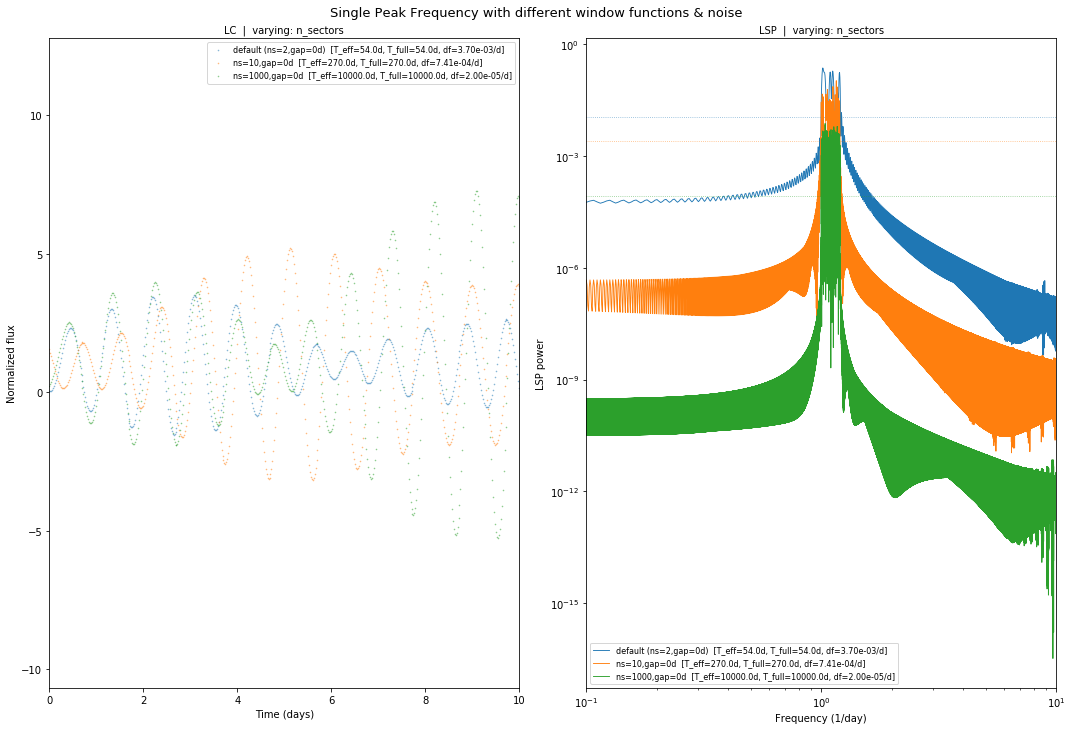

{'n_sectors': {'default (ns=2,gap=0d)  [T_eff=54.0d, T_full=54.0d, df=3.70e-03/d]': {'freqs': array([0.1       , 0.1037037 , 0.10740741, ..., 9.98888889, 9.99259259,
          9.9962963 ]),
   'power': array([5.75345570e-05, 6.22976512e-05, 6.51232752e-05, ...,
          1.60600100e-07, 8.55095074e-08, 5.99648354e-09]),
   'max_power': 0.23225654597376916,
   'freq_at_max_power': 1.0148148148148148,
   'period_at_max_power': 0.9854014598540146,
   'fap_threshold': 0.01132460041041661,
   'SumPow_10_7': 0.0007198616567137234,
   'SumPow_7_4': 0.0018024972700182262,
   'SumPow_4_1': 0.08615042624376443,
   'SumPow_1_p5': 4.935284086868632},
  'ns=10,gap=0d  [T_eff=270.0d, T_full=270.0d, df=7.41e-04/d]': {'freqs': array([0.1       , 0.10074074, 0.10148148, ..., 9.99777778, 9.99851852,
          9.99925926]),
   'power': array([4.73678762e-07, 3.46985024e-07, 9.91132816e-08, ...,
          2.41925524e-09, 5.81624069e-10, 1.04915506e-10]),
   'max_power': 0.10541665630600029,
   'freq_at_ma

In [30]:
BASE_CONFIG = dict(
    # Oscillator
    N                  = [1000],
    freq_distribution  = ['uniform'],
    freq               = [1.0],
    freq_width         = [0.2],
    amp_distribution   = ['uniform'],
    amp                = [0.1],
    amp_width          = [0],

    # LC / window  (n_sectors: list of (n_sectors, gap_durations) tuples)
    FullLC_Baseline    = 10000,
    sector_length      = [27.0],
    cadence            = [30.0],
    n_sectors          = [(2, [0]),
                          (10, [0]*9),
                          (1000, [0]*999),

                         ],

    # Noise
    sigma              = [0],

    # LSP
    T_effective        = [False],
    P_min              = [0.1],
    P_max              = [10],
    alpha              = [5],
)

run_configs(
    BASE_CONFIG,
    title='Single Peak Frequency with different window functions & noise',
    yscale='log',
    xscale='log',
    #x_lim=(0.95, 1.3),
    figsize=(15, 10),
    multipanel=True,
    plot_LC=True,
    LC_xlim=[0, 10],
)

/astro/users/cgwill/TESS_Cluster_Age_ML/Data_Visualization_CGW/synthetic_lc.py:895: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/epyc/opt/anaconda/lib/python3.7/site-packages/IPython/core/pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


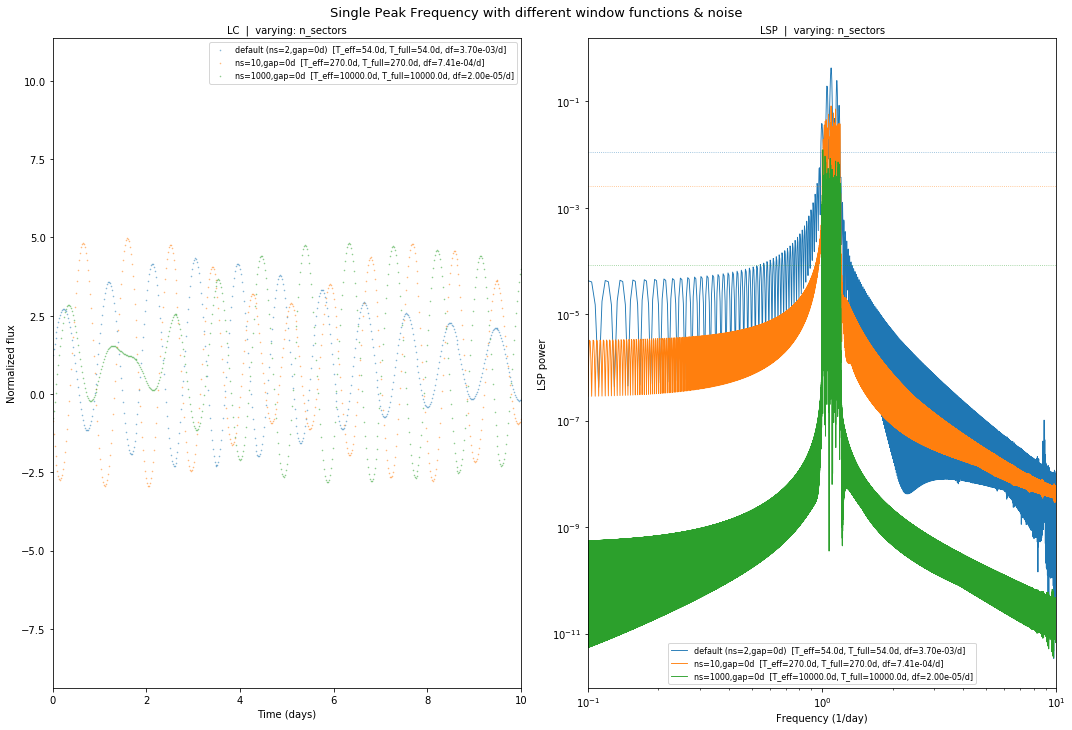

{'n_sectors': {'default (ns=2,gap=0d)  [T_eff=54.0d, T_full=54.0d, df=3.70e-03/d]': {'freqs': array([0.1       , 0.1037037 , 0.10740741, ..., 9.98888889, 9.99259259,
          9.9962963 ]),
   'power': array([4.28207606e-05, 4.05417741e-05, 1.50461919e-05, ...,
          8.92876203e-09, 3.83659776e-09, 4.77974279e-11]),
   'max_power': 0.42480376331625064,
   'freq_at_max_power': 1.0925925925925926,
   'period_at_max_power': 0.9152542372881356,
   'fap_threshold': 0.01132460041041661,
   'SumPow_10_7': 0.0003185483122311074,
   'SumPow_7_4': 0.0006983221675137556,
   'SumPow_4_1': 0.1793186861155248,
   'SumPow_1_p5': 4.853599422804017},
  'ns=10,gap=0d  [T_eff=270.0d, T_full=270.0d, df=7.41e-04/d]': {'freqs': array([0.1       , 0.10074074, 0.10148148, ..., 9.99777778, 9.99851852,
          9.99925926]),
   'power': array([2.87397916e-07, 1.49754668e-06, 3.25715611e-06, ...,
          3.58041460e-09, 3.42217595e-09, 4.59475905e-09]),
   'max_power': 0.08206710815782527,
   'freq_at_max

In [34]:
BASE_CONFIG = dict(
    # Oscillator
    N                  = [1000],
    freq_distribution  = ['uniform'],
    freq               = [1.0],
    freq_width         = [0.2],
    amp_distribution   = ['uniform'],
    amp                = [0.1],
    amp_width          = [0],

    # LC / window  (n_sectors: list of (n_sectors, gap_durations) tuples)
    FullLC_Baseline    = 10000,
    sector_length      = [27.0],
    cadence            = [30.0],
    n_sectors          = [(2, [0]),
                          (10, [0]*9),
                          (1000, [0]*999),

                         ],

    # Noise
    sigma              = [0],

    # LSP
    T_effective        = [False],
    P_min              = [0.1],
    P_max              = [10],
    alpha              = [5],
)

run_configs(
    BASE_CONFIG,
    title='Single Peak Frequency with different window functions & noise',
    yscale='log',
    xscale='log',
    #x_lim=(0.95, 1.3),
    figsize=(15, 10),
    multipanel=True,
    plot_LC=True,
    LC_xlim=[0, 10],
)

# Test

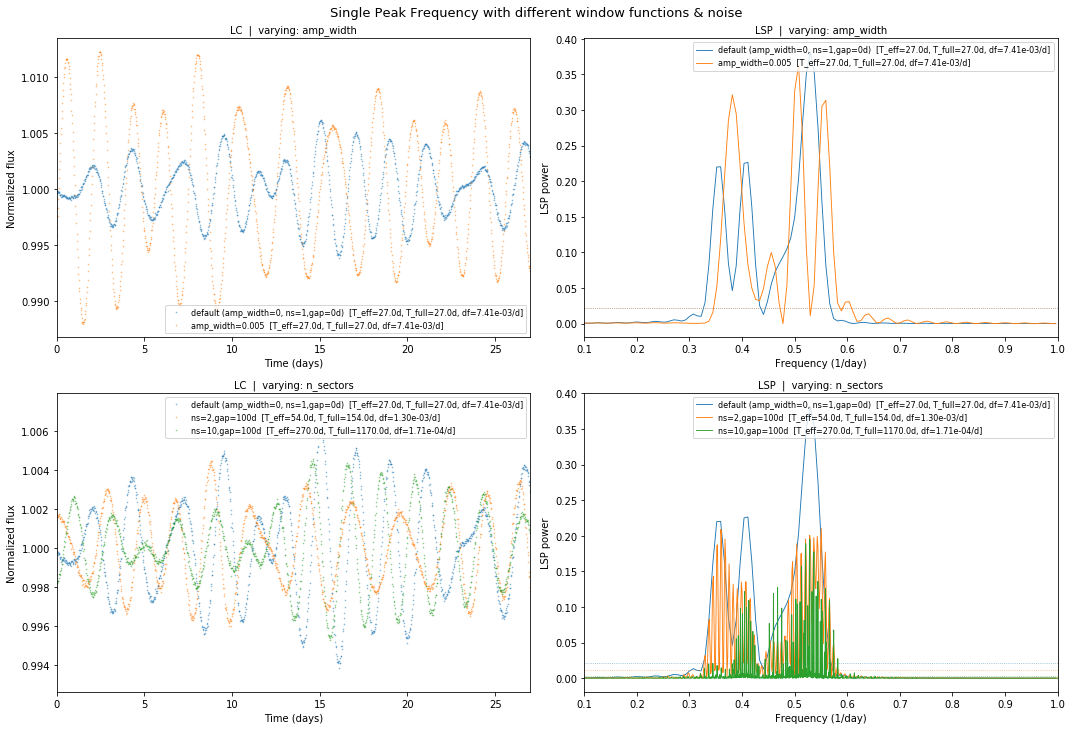

{'amp_width': {'default (amp_width=0, ns=1,gap=0d)  [T_eff=27.0d, T_full=27.0d, df=7.41e-03/d]': {'freqs': array([0.1       , 0.10740741, 0.11481481, ..., 9.97407407, 9.98148148,
          9.98888889]),
   'power': array([8.51687729e-04, 5.89614469e-04, 6.95101015e-04, ...,
          3.37750154e-06, 3.05595073e-06, 1.77630820e-06]),
   'max_power': 0.38161064552970414,
   'freq_at_max_power': 0.5296296296296297,
   'period_at_max_power': 1.888111888111888,
   'fap_threshold': 0.02145815094091086,
   'SumPow_10_7': 0.005262076288134734,
   'SumPow_7_4': 0.02629855200969471,
   'SumPow_4_1': 4.9356494033048675,
   'SumPow_1_p5': 0.008006423430355817},
  'amp_width=0.005  [T_eff=27.0d, T_full=27.0d, df=7.41e-03/d]': {'freqs': array([0.1       , 0.10740741, 0.11481481, ..., 9.97407407, 9.98148148,
          9.98888889]),
   'power': array([7.50174049e-04, 7.71883077e-04, 8.70406768e-04, ...,
          2.07157065e-06, 1.30765463e-06, 6.41775046e-07]),
   'max_power': 0.36344380068801396,
  

In [66]:
BASE_CONFIG = dict(
    # Oscillator
    N                  = [10],
    freq_distribution  = ['uniform'],
    freq               = [0.3],
    freq_width         = [0.3],
    amp_distribution   = ['uniform'],
    amp                = [0.001],
    amp_width          = [0, 0.005],

    # LC / window  (n_sectors: list of (n_sectors, gap_durations) tuples)
    FullLC_Baseline    = 10000,
    sector_length      = [27.0],
    cadence            = [30.0],
    n_sectors          = [(1, []),
                          (2, [100]),
                          (10, [100]*9),

                         ],

    # Noise
    sigma              = [0.0001],

    # LSP
    T_effective        = [False],
    P_min              = [0.1],
    P_max              = [10],
    alpha              = [5],
)

run_configs(
    BASE_CONFIG,
    title='Single Peak Frequency with different window functions & noise',
    yscale='linear',
    xscale='linear',
    x_lim=(0.1, 1),
    figsize=(15, 10),
    multipanel=True,
    plot_LC=True,
    LC_xlim=[0, 27],
)